In [2]:
import tables
from ctapipe.visualization import CameraDisplay
from ctapipe.coordinates import EngineeringCameraFrame
from ctapipe_io_lst import LSTEventSource
import matplotlib.pyplot as plt
import numpy as np


# CAMERA GEOMETRY------ 
sa = LSTEventSource.create_subarray(tel_id=1)
focal_length = sa.tel[1].optics.equivalent_focal_length
camera_geom = sa.tel[1].camera.geometry


# RUN ID'S TO LOOK
run_id_list = ['01620']

for run_id in run_id_list:
# READING RESULTS -------------------------------------------------------------------------------------------------------------------------------
    print("\n" + "="*80)
    print(f"Run {run_id}")
    print("="*80)
    b = tables.open_file(r"/data/cta/users-ifae/summer_students/agl/6y_checks/checks_Run{run_id}.h5".format(run_id= run_id))
    for filt in ["filter1", "filter2", "filter2a", "filter2b", "filter2c"]:
    
        table = getattr(b.root.perfilter, filt)
        fit_table = getattr(b.root.perfilter, f"{filt}_fit")
        points_table = getattr(b.root.perfilter, f"{filt}_points")
    
        print(f"\n{'='*60}")
        print(f"{filt.upper()}")
        print(f"{'='*60}")
    
        # ---------------- FIT ----------------
        fit = fit_table[0]
    
        print(f"Valid fit : {fit['valid']}")
    
        print("Fit parameters:")
        print(f"  slope     = {fit['slope']:.6f} ± {fit['u_slope']:.6f}")
        print(f"  intercept = {fit['intercept']:.6f} ± {fit['u_intercept']:.6f}")
    
        # ---------------- CHECKS ----------------
        print("\nChecks:")
    
        if len(table) == 0:
            print("  None")
        else:
            sigma_cutoff = table[0]["sigma_cutoff"]
            print(f"Sigma cutoff = {sigma_cutoff}")
    
            print(f"\n{'Subrun':>8} {'z-score':>10}")
            print("-"*20)
    
            for row in table:
                print(f"{row['check_index']:>8} {row['z_score']:>10.3f}")


Run 01620

FILTER1
Valid fit : True
Fit parameters:
  slope     = -0.469019 ± 0.053318
  intercept = 2280.970386 ± 2.347194

Checks:
  None

FILTER2
Valid fit : True
Fit parameters:
  slope     = -0.000006 ± 0.000007
  intercept = 0.004607 ± 0.000307

Checks:
  None

FILTER2A
Valid fit : True
Fit parameters:
  slope     = -0.000051 ± 0.000034
  intercept = 0.018856 ± 0.001486

Checks:
  None

FILTER2B
Valid fit : True
Fit parameters:
  slope     = 0.000006 ± 0.000007
  intercept = 0.004169 ± 0.000318

Checks:
  None

FILTER2C
Valid fit : True
Fit parameters:
  slope     = 0.000035 ± 0.000026
  intercept = 0.013777 ± 0.001104

Checks:
  None


In [21]:
for run_id in run_id_list:
    b = tables.open_file(r"/data/cta/users-ifae/summer_students/agl/6y_checks/checks_Run{run_id}.h5".format(run_id= run_id))

b.root.perfilter.filter1_fit[0]["slope"]

np.float64(-0.46901880162766196)

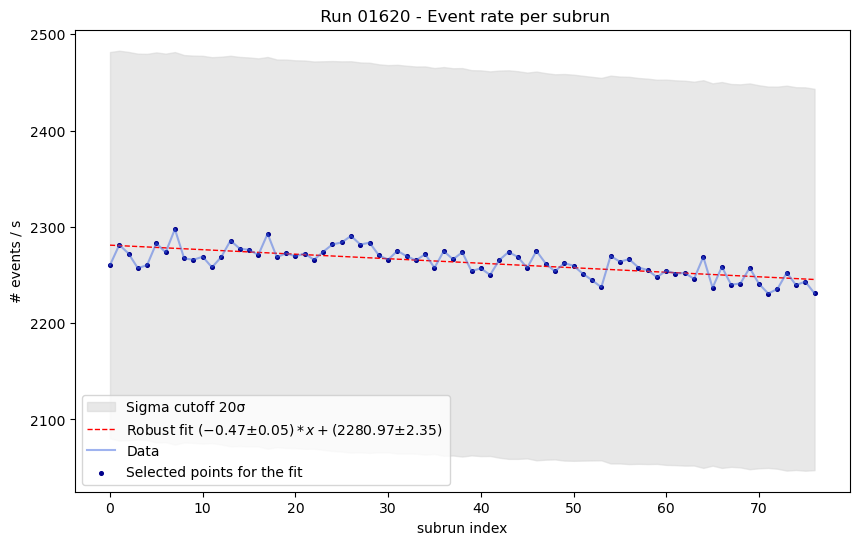

In [23]:
# FILTER 1: EVENT RATE VS SUBRUN-----------------------------------------------------------
for run_id in run_id_list:
    b = tables.open_file(r"/data/cta/users-ifae/summer_students/agl/6y_checks/checks_Run{run_id}.h5".format(run_id= run_id))
    
    if b.root.perfilter.filter1_fit.col('valid')[0]:
        a = tables.open_file(r"/data/cta/users-ifae/moralejo/CTA/summer_student_2026/datacheck/ALL_h5/datacheck_dl1_LST-1.Run{run_id}.h5".format(run_id= run_id))
        
        subruns = a.root.dl1datacheck.cosmics.col('subrun_index')[:-1] #0,1,...,57 number of subruns in this run
        n_subruns = len(subruns)
        time = a.root.dl1datacheck.cosmics.col('elapsed_time')[:-1]
        
        num_events = a.root.dl1datacheck.cosmics.col('num_events')[:-1] # events in each subrun
        event_rate = num_events / time
        event_rate_sigma = np.sqrt(np.maximum(num_events, 1.0)) / time  
        
        # ROBUST FIT PARAMETES
        x_fit = np.linspace(min(subruns), max(subruns), n_subruns)
        fit_1 = b.root.perfilter.filter1_fit[0]
        fit_slope = fit_1["slope"]
        fit_u_slope = fit_1["u_slope"]
        fit_intercept = fit_1["intercept"]
        fit_u_intercept = fit_1["u_intercept"]
        event_rate_fit = fit_slope * x_fit + fit_intercept

        # SIGMA CUTOFF
        sigma_cutoff_1 = 20

        # SELECTED POINTS FOR THE FIT
        points = b.root.perfilter.filter1_points
        plt.figure(figsize=(10, 6))
        plt.fill_between(
            subruns,
            event_rate_fit - sigma_cutoff_1 * event_rate_sigma,
            event_rate_fit + sigma_cutoff_1* event_rate_sigma,
            color='lightgray', alpha= 0.5, label=f'Sigma cutoff {sigma_cutoff_1}σ'
        )
        plt.plot(subruns, event_rate_fit, label=f'Robust fit $({fit_slope:.2f}±{fit_u_slope:.2f}) * x + ({fit_intercept:.2f}±{fit_u_intercept:.2f})$ ', color='red', linestyle='--', linewidth=1)
        plt.plot(subruns, event_rate, color='royalblue', alpha=0.5, label='Data')
        plt.scatter(points.col("x"), points.col("y"), color="darkblue", s=7, label="Selected points for the fit")
        plt.title(f' Run {run_id} - Event rate per subrun')
        plt.ylabel('# events / s')
        plt.xlabel('subrun index')
        plt.legend()
        plt.show()
        
    else:
        print(f'Filter 1 is not valid for run {run_id}')
        
    a.close()
    b.close()

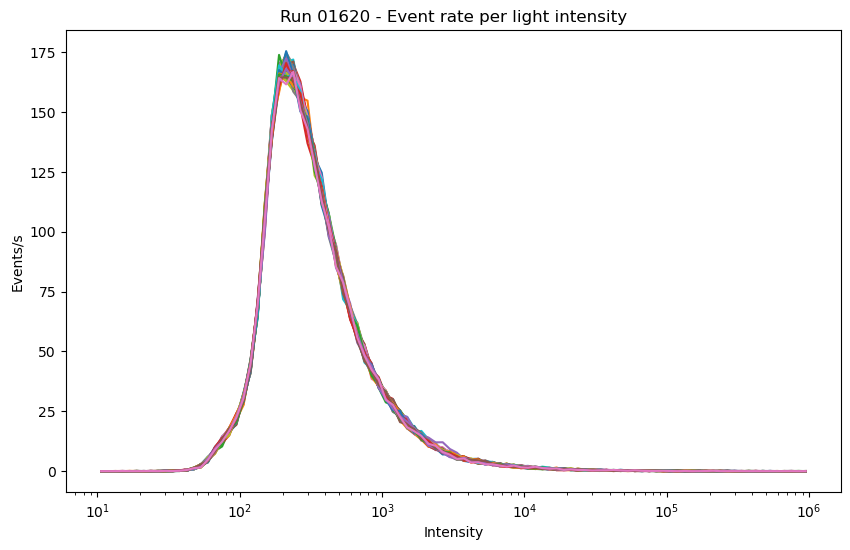

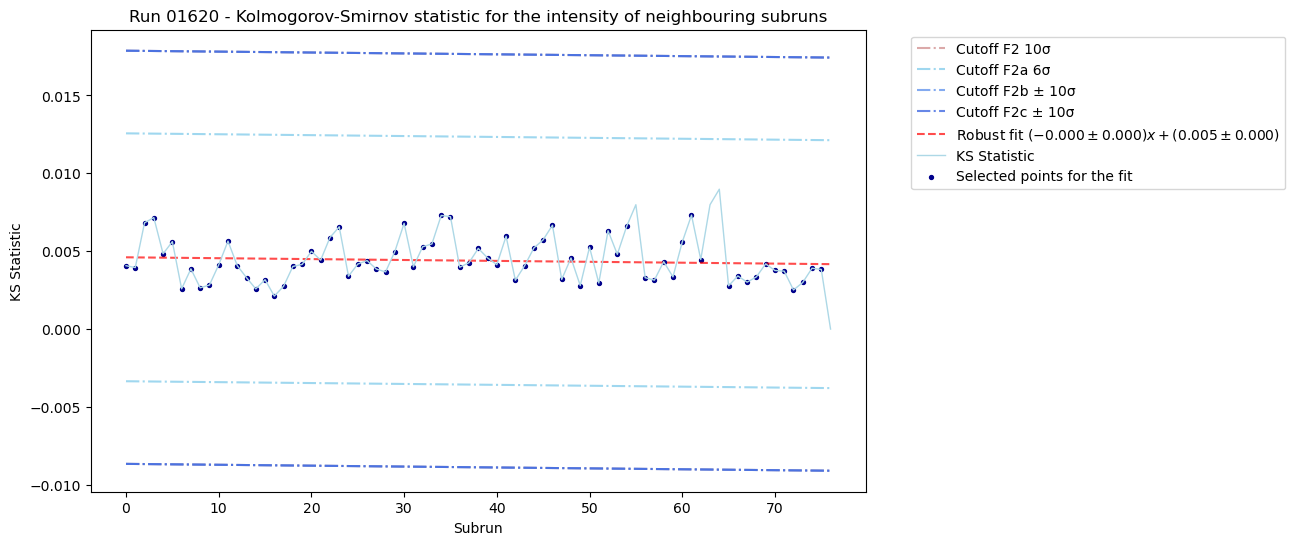

In [26]:
# FILTER 2: EVENT RATE VS INTENSITY------------------------------------------------------
for run_id in run_id_list:
    b = tables.open_file(r"/data/cta/users-ifae/summer_students/agl/6y_checks/checks_Run{run_id}.h5".format(run_id=run_id))

    if b.root.perfilter.filter2_fit.col("valid")[0]:

        a = tables.open_file(r"/data/cta/users-ifae/moralejo/CTA/summer_student_2026/datacheck/ALL_h5/datacheck_dl1_LST-1.Run{run_id}.h5".format(run_id=run_id))

        subruns = a.root.dl1datacheck.cosmics.col('subrun_index')[:-1]
        time = a.root.dl1datacheck.cosmics.col('elapsed_time')[:-1]
        hist_intensity = a.root.dl1datacheck.cosmics.col('hist_intensity')[:-1]
        intensity_bins = a.root.dl1datacheck.histogram_binning.col('hist_intensity')[0]
        intensity = 0.5 * (intensity_bins[1:] + intensity_bins[:-1])

        cdf = np.cumsum(
            hist_intensity / np.maximum(hist_intensity.sum(axis=1, keepdims=True), 1),
            axis=1,
        )  # we need to normalize the histogram. 1 cdf per subrun

        D = np.zeros(len(subruns))

        for s in range(0, len(subruns) - 1):
            D[s] = np.max(np.abs(cdf[s] - cdf[s + 1]))  # we compare the CDF in each subrun 's' with its neighbouring one 's+1'

        # ROBUST FIT PARAMETERS
        fit_2 = b.root.perfilter.filter2_fit[0]
        fit_slope = fit_2["slope"]
        fit_u_slope = fit_2["u_slope"]
        fit_intercept = fit_2["intercept"]
        fit_u_intercept = fit_2["u_intercept"]

        D_fit = fit_slope * subruns + fit_intercept

        # SELECTED POINTS FOR THE FIT
        points = b.root.perfilter.filter2_points

        D_good = points.col("y")
        D_fit_good = fit_slope * points.col("x") + fit_intercept

        sigma_2 = np.std(D_good - D_fit_good)

        sigma_cutoff_2 = 10
        sigma_cutoff_2a = 6
        sigma_cutoff_2b = 10
        sigma_cutoff_2c = 10

        # This is not a Poisson process therefore we cannot treat it as such

        # PLOT INTENSITIES
        checks = b.root.general.cosmics.col("subrun_index")
        plt.figure(figsize=(10, 6))

        for s in range(hist_intensity.shape[0]):
            event_rate_i = hist_intensity[s] / time[s]
            if s in checks:
                plt.plot(intensity, event_rate_i, linestyle='--', label=f'Subrun{s}')
            else:
                plt.plot(intensity, event_rate_i)

        plt.title(f'Run {run_id} - Event rate per light intensity')
        plt.xlabel('Intensity')
        plt.ylabel('Events/s')
        plt.xscale('log')
        plt.show()
        
        # PLOT KOLMOGOROV
        plt.figure(figsize=(10, 6))
        plt.plot(subruns, D_fit + sigma_cutoff_2 * sigma_2, color='brown', linestyle='-.', alpha=0.4, label=f'Cutoff F2 {sigma_cutoff_2}σ')
        plt.plot(subruns, D_fit - sigma_cutoff_2 * sigma_2, color='brown', linestyle='-.', alpha=0.4)
        plt.plot(subruns, D_fit + sigma_cutoff_2a * sigma_2, color='skyblue', linestyle='-.', alpha=0.8, label=f'Cutoff F2a {sigma_cutoff_2a}σ')
        plt.plot(subruns, D_fit - sigma_cutoff_2a * sigma_2, color='skyblue', linestyle='-.', alpha=0.8)
        plt.plot(subruns, D_fit + sigma_cutoff_2b * sigma_2, color='cornflowerblue', linestyle='-.', alpha=0.8, label=f'Cutoff F2b ± {sigma_cutoff_2b}σ')
        plt.plot(subruns, D_fit - sigma_cutoff_2b * sigma_2, color='cornflowerblue', linestyle='-.', alpha=0.8)
        plt.plot(subruns, D_fit + sigma_cutoff_2c * sigma_2, color='royalblue', linestyle='-.', alpha=0.8, label=f'Cutoff F2c ± {sigma_cutoff_2c}σ')
        plt.plot(subruns, D_fit - sigma_cutoff_2c * sigma_2, color='royalblue', linestyle='-.', alpha=0.8)
        
        plt.plot(subruns, D_fit, label=f'Robust fit $({fit_slope:.3f} \pm {fit_u_slope:.3f})x + ({fit_intercept:.3f} \pm {fit_u_intercept:.3f})$', alpha=0.7, color='red', linestyle='--')
        plt.plot(subruns, D, linewidth=1, color='lightblue', label='KS Statistic')
        plt.scatter(points.col("x"), points.col("y"), s=8, color="darkblue", label="Selected points for the fit")
        
        plt.xlabel('Subrun')
        plt.ylabel('KS Statistic')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.title(f'Run {run_id} - Kolmogorov-Smirnov statistic for the intensity of neighbouring subruns')
        plt.show()

        a.close()

    else:
        print(f"Filter 2 is not valid for run {run_id}")

    b.close()

In [28]:
for run_id in run_id_list:
    b = tables.open_file(r"/data/cta/users-ifae/summer_students/agl/6y_checks/checks_Run{run_id}.h5".format(run_id= run_id))
    a = tables.open_file(r"/data/cta/users-ifae/moralejo/CTA/summer_student_2026/datacheck/ALL_h5/datacheck_dl1_LST-1.Run{run_id}.h5".format(run_id= run_id))
    time = a.root.dl1datacheck.cosmics.col('elapsed_time')[:-1]
    cog_pixel = a.root.dl1datacheck.cosmics.col('cog_within_pixel')[:-1]  # shape: (n_subruns, n_pixels)
    cog_rate = cog_pixel / time[:, None]
    
    checks = b.root.general.cosmics.col("subrun_index")
    
    subruns = a.root.dl1datacheck.cosmics.col('subrun_index')[:-1]
    subrun_to_row = {subrun: row for row, subrun in enumerate(subruns)}
    
    for subrun in checks:
        row = subrun_to_row[subrun]
    
        camdisplay = CameraDisplay(
            camera_geom.transform_to(EngineeringCameraFrame()),
            norm="lin",
            title=f"Run {run_id} - Rate of events with CoG in pixel in subrun {subrun}",
            image=cog_rate[row, :]
        )
        camdisplay.autoupdate = True
        camdisplay.add_colorbar()
        plt.show()
    b.close()
    a.close()
